# Modeling

After understanding the dataset, analyzing its linguistic characteristics and preprocessing it for machine learning in the previous notebooks, the focus of this notebook is on building, evaluating, and saving multiple baseline models for sentiment classification.

In [81]:
import sys
from pathlib import Path

project_root = Path().resolve()
while not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))

In [82]:
from src.utils.utils import load_config
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from src.data.clean_data import cleaning_transformer
from src.models.train_model import train_model
from src.models.evaluate_model import evaluate_model

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

## Loading preprocessed data

In [83]:
config = load_config("configs/config.yaml")

df = pd.read_csv(config['data']['preprocessed_path'], keep_default_na=False)
df.head()

,text,label,clean_text
0,"According to Gran , the company has no plans t...",neutral,according gran company ha plan move production...
1,"For the last quarter of 2010 , Componenta 's n...",positive,last quarter componenta net sale doubled perio...
2,"In the third quarter of 2010 , net sales incre...",positive,third quarter net sale increased eur mn operat...
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,operating profit rose eur mn eur mn correspond...
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,operating profit totalled eur mn eur mn repres...


## Splitting Data

In [84]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training Models

In [85]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

In [86]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    trained = train_model(model, X_train, y_train, None, None, 3000, (1,2))
    trained_models[name] = trained
    print("Training successfull!")

Training Logistic Regression...
Training successfull!
Training Linear SVM...
Training successfull!
Training Naive Bayes...
Training successfull!


In [87]:
trained_models

{'Logistic Regression': Pipeline(steps=[('clean',
                  FunctionTransformer(func=<function cleaning_transformer.<locals>.<lambda> at 0x7f4aec48e160>)),
                 ('tfidf',
                  TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                 ('clf', LogisticRegression(max_iter=1000))]),
 'Linear SVM': Pipeline(steps=[('clean',
                  FunctionTransformer(func=<function cleaning_transformer.<locals>.<lambda> at 0x7f4aec2f0220>)),
                 ('tfidf',
                  TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                 ('clf', LinearSVC())]),
 'Naive Bayes': Pipeline(steps=[('clean',
                  FunctionTransformer(func=<function cleaning_transformer.<locals>.<lambda> at 0x7f4aec2f04a0>)),
                 ('tfidf',
                  TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                 ('clf', MultinomialNB())])}

## Evaluating models

=== Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.86      0.51      0.64        61
     neutral       0.86      0.96      0.91       278
    positive       0.75      0.70      0.72       114

    accuracy                           0.84       453
   macro avg       0.82      0.72      0.76       453
weighted avg       0.83      0.84      0.83       453



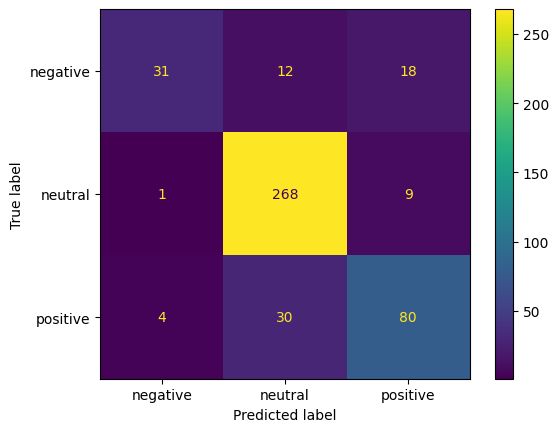



=== Linear SVM ===
              precision    recall  f1-score   support

    negative       0.80      0.79      0.79        61
     neutral       0.95      0.98      0.96       278
    positive       0.87      0.80      0.83       114

    accuracy                           0.91       453
   macro avg       0.87      0.86      0.86       453
weighted avg       0.91      0.91      0.91       453



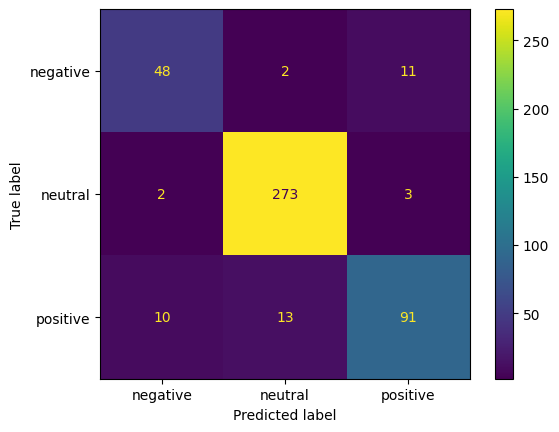



=== Naive Bayes ===
              precision    recall  f1-score   support

    negative       1.00      0.23      0.37        61
     neutral       0.87      0.95      0.91       278
    positive       0.63      0.75      0.69       114

    accuracy                           0.80       453
   macro avg       0.83      0.64      0.65       453
weighted avg       0.83      0.80      0.78       453



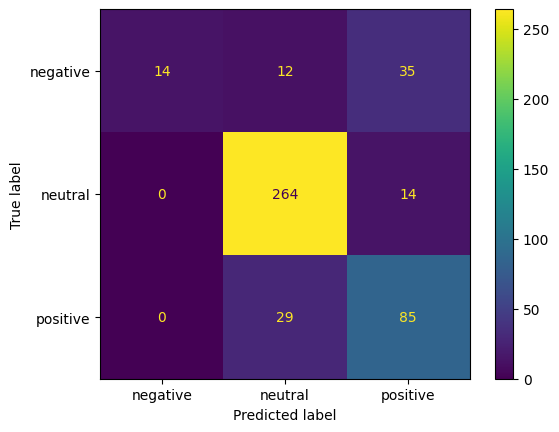

In [88]:
for name, model in trained_models.items():
    print(f"=== {name} ===")
    evaluate_model(model, X_test, y_test)
    print("\n")